In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 데이터 로드 (상대 경로 적용)
BASE_DIR = ".."
DATA_PATH = os.path.join(BASE_DIR, 'rawData', 'water_quality_training_dataset.csv')

df = pd.read_csv(DATA_PATH)

# 2. 기초 정보 확인
print("--- [Dataset Info] ---")
print(df.info())
print("\n--- [Basic Statistics] ---")
display(df.describe())

# 3. 타겟(Target) 분포 시각화 (회귀/분류 확인)
plt.figure(figsize=(10, 5))
sns.histplot(df['target'], kde=True, color='teal')
plt.title('Distribution of Water Quality Index (Target)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. 지리적 분포 (Latitude & Longitude)
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], c=df['target'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Target Value')
plt.title('Geospatial Distribution of Samples')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# 5. 결측치(Missing Values) 체크
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("\n⚠️ 결측치 발견:")
    print(missing_values[missing_values > 0])
else:
    print("\n✔ 결측치 없음. 데이터가 깨끗합니다.")

--- [Dataset Info] ---
<class 'pandas.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Latitude                       9319 non-null   float64
 1   Longitude                      9319 non-null   float64
 2   Sample Date                    9319 non-null   str    
 3   Total Alkalinity               9319 non-null   float64
 4   Electrical Conductance         9319 non-null   float64
 5   Dissolved Reactive Phosphorus  9319 non-null   float64
dtypes: float64(5), str(1)
memory usage: 437.0 KB
None

--- [Basic Statistics] ---


,Latitude,Longitude,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
count,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,-28.474988,26.868414,119.108208,485.004146,43.525338
std,2.760282,3.535164,74.692591,341.937736,50.980194
min,-34.405833,17.730278,4.800000,15.120000,5.000000
25%,-30.160091,26.126667,55.811000,207.050000,10.000000
50%,-28.058889,27.409060,113.300000,402.000000,20.000000
75%,-26.861111,29.245556,170.230000,693.000000,48.000000
max,-22.225556,32.325000,361.676000,1506.000000,195.000000


KeyError: 'target'

<Figure size 1000x500 with 0 Axes>

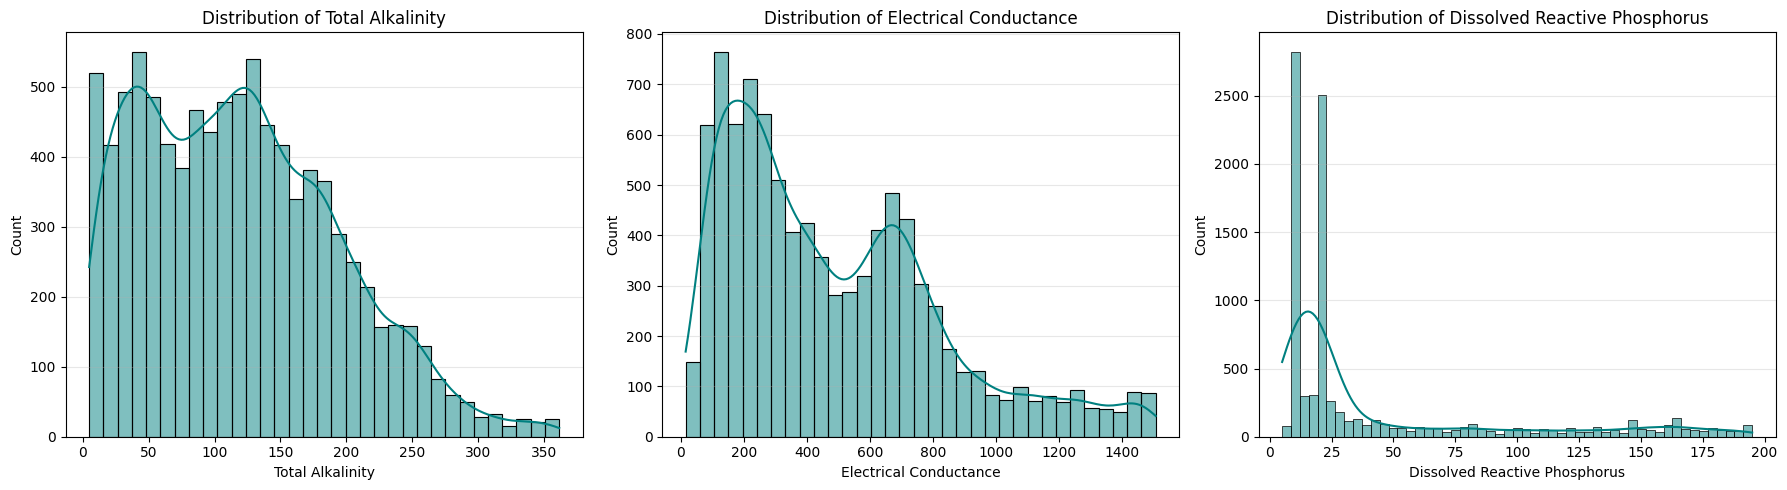

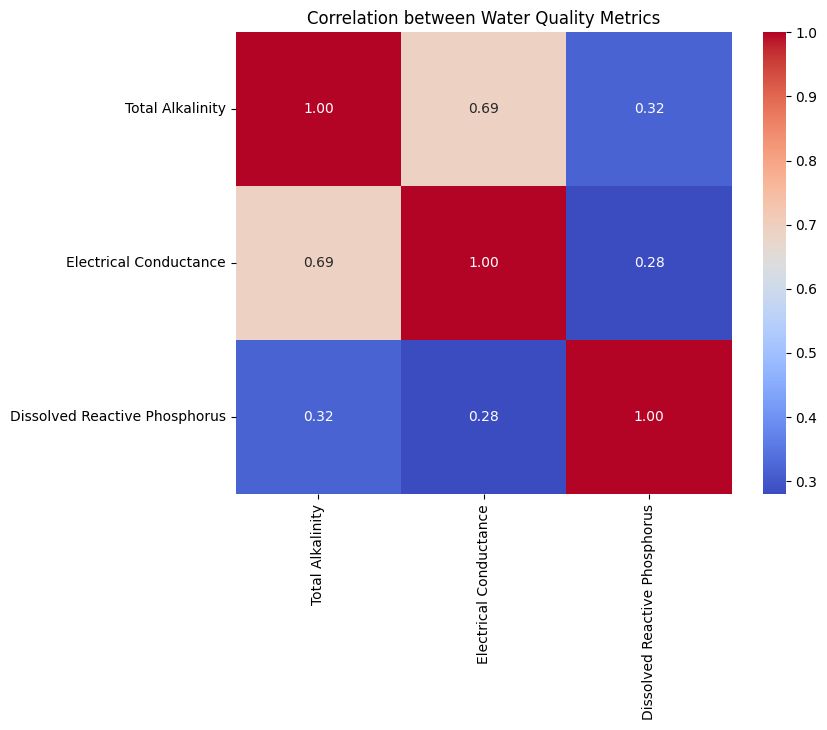

In [4]:
#수질분석
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 데이터 로드
BASE_DIR = ".."
DATA_PATH = os.path.join(BASE_DIR, 'rawData', 'water_quality_training_dataset.csv')
df = pd.read_csv(DATA_PATH)

# 2. 타겟 컬럼 리스트
target_cols = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

# 3. 타겟 지표별 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 지표 간 상관관계 분석 (Correlation Matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(df[target_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Water Quality Metrics')
plt.show()